Mounted at /content/drive

Feature Importance

                        Feature       FI
13                   root_shell 0.519751
37         dst_host_serror_rate 0.083710
22                        count 0.049881
10            num_failed_logins 0.048045
32           dst_host_srv_count 0.041860
1                 protocol_type 0.034272
41                   difficulty 0.028852
4                     src_bytes 0.027637
28                same_srv_rate 0.023452
34       dst_host_diff_srv_rate 0.018472
5                     dst_bytes 0.017979
29                diff_srv_rate 0.017251
2                       service 0.015097
7                wrong_fragment 0.012884
21               is_guest_login 0.008039
39         dst_host_rerror_rate 0.006959
15                     num_root 0.005717
31               dst_host_count 0.004532
12              num_compromised 0.004394
24                  serror_rate 0.004081
33       dst_host_same_srv_rate 0.003687
8                        urgent 0.003078
3         

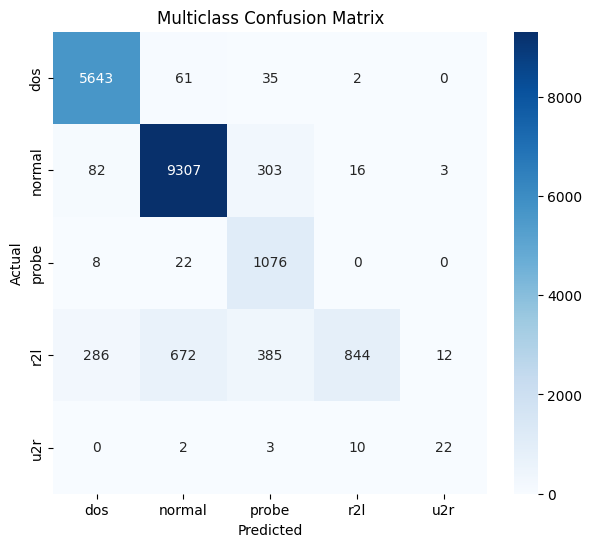


Computing SHAP...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Received: inputs=['Tensor(shape=(1, 22, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Received: inputs=['Tensor(shape=(50, 22, 1))']
  warnings.warn(msg)
/tmp/ipykernel_1208/1317564509.py:285: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng

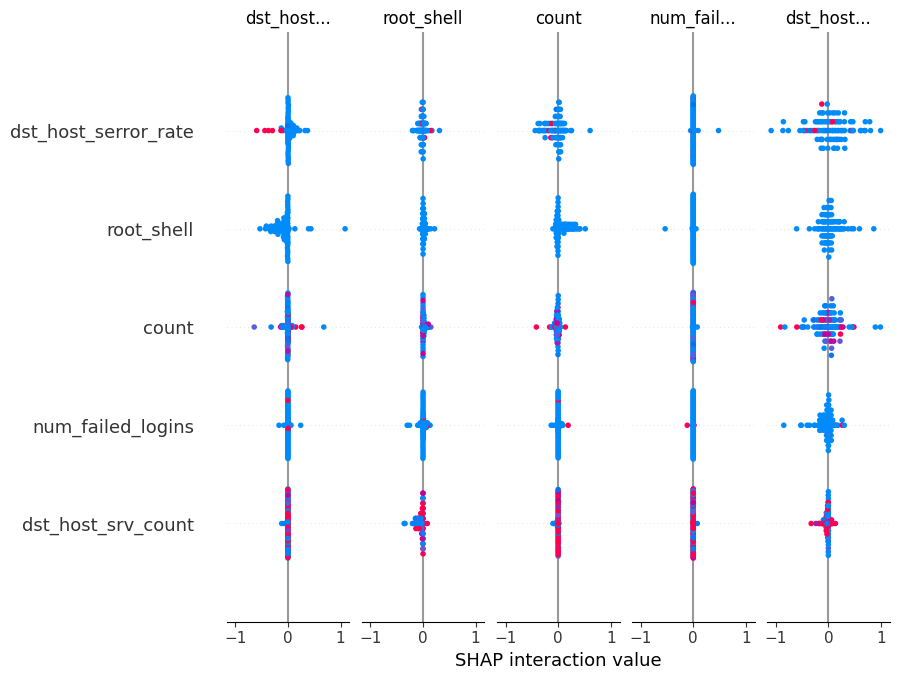

In [2]:
# =========================================================
# FINAL MULTICLASS GRU (BALANCED + ATTENTION + SHAP + CM)
# =========================================================

import pandas as pd
import numpy as np
import tensorflow as tf
import random
import time
import shap
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils import resample, compute_class_weight

from xgboost import XGBClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.layers import Softmax, Multiply, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# =========================================================
# SETUP
# =========================================================
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

pd.set_option('display.float_format', '{:.6f}'.format)

# =========================================================
# LOAD DATA
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

base="/content/drive/MyDrive/NSL-KDD/"
train_df=pd.read_csv(base+"KDDTrain.csv")
test_df=pd.read_csv(base+"KDDTest+.csv")

train_df['label']=train_df['label'].str.replace('.','',regex=False)
test_df['label']=test_df['label'].str.replace('.','',regex=False)

# =========================================================
# MULTICLASS MAPPING
# =========================================================
attack_map = {
 'normal':'normal',
 'neptune':'dos','back':'dos','land':'dos','pod':'dos','smurf':'dos','teardrop':'dos',
 'ipsweep':'probe','nmap':'probe','portsweep':'probe','satan':'probe',
 'ftp_write':'r2l','guess_passwd':'r2l','imap':'r2l','multihop':'r2l',
 'phf':'r2l','spy':'r2l','warezclient':'r2l','warezmaster':'r2l',
 'buffer_overflow':'u2r','loadmodule':'u2r','perl':'u2r','rootkit':'u2r'
}

train_df['label']=train_df['label'].map(attack_map)
test_df['label']=test_df['label'].map(attack_map)

train_df=train_df.dropna(subset=['label'])
test_df=test_df.dropna(subset=['label'])

# =========================================================
# BALANCING (SMART)
# =========================================================
df_normal=train_df[train_df.label=="normal"]
df_dos=train_df[train_df.label=="dos"]
df_probe=train_df[train_df.label=="probe"]
df_r2l=train_df[train_df.label=="r2l"]
df_u2r=train_df[train_df.label=="u2r"]

target=60000

df_dos=resample(df_dos,replace=True,n_samples=target,random_state=42)
df_probe=resample(df_probe,replace=True,n_samples=target,random_state=42)
df_r2l=resample(df_r2l,replace=True,n_samples=target,random_state=42)
df_u2r=resample(df_u2r,replace=True,n_samples=target,random_state=42)

train_df=pd.concat([df_normal,df_dos,df_probe,df_r2l,df_u2r])

# =========================================================
# SPLIT
# =========================================================
train_df,val_df=train_test_split(
    train_df,test_size=0.25,stratify=train_df['label'],random_state=42
)

# =========================================================
# PREPROCESS
# =========================================================
def preprocess(df):
    X=df.drop("label",axis=1)
    y=df["label"]

    for col in ["protocol_type","service","flag"]:
        X[col]=LabelEncoder().fit_transform(X[col])

    X=MinMaxScaler().fit_transform(X)
    return X,y

X_train,y_train=preprocess(train_df)
X_val,y_val=preprocess(val_df)
X_test,y_test=preprocess(test_df)

# =========================================================
# LABEL ENCODING
# =========================================================
le=LabelEncoder()
y_train_enc=le.fit_transform(y_train)
y_val_enc=le.transform(y_val)
y_test_enc=le.transform(y_test)

num_classes=len(le.classes_)

y_train_cat=tf.keras.utils.to_categorical(y_train_enc)
y_val_cat=tf.keras.utils.to_categorical(y_val_enc)

# =========================================================
# CLASS WEIGHTS
# =========================================================
weights=compute_class_weight("balanced",classes=np.unique(y_train_enc),y=y_train_enc)
class_weights=dict(enumerate(weights))

# =========================================================
# XGBOOST FEATURE SELECTION
# =========================================================
print("\nFeature Importance\n")

xgb=XGBClassifier(n_estimators=200,max_depth=6)
xgb.fit(X_train,y_train_enc)

feature_names=train_df.drop("label",axis=1).columns

feat_df=pd.DataFrame({
    "Feature":feature_names,
    "FI":xgb.feature_importances_
}).sort_values("FI",ascending=False)

print(feat_df)

top_features=feat_df.head(22)

print("\nTop 22 Features\n")
print(top_features)

idx=[list(feature_names).index(f) for f in top_features["Feature"]]

X_train=X_train[:,idx].reshape(-1,len(idx),1)
X_val=X_val[:,idx].reshape(-1,len(idx),1)
X_test=X_test[:,idx].reshape(-1,len(idx),1)

# =========================================================
# MODEL
# =========================================================
def build_model(nu):

    inp=Input(shape=(len(idx),1))

    x=Bidirectional(GRU(nu,return_sequences=True))(inp)
    x=BatchNormalization()(x)
    x=Dropout(0.2)(x)

    x=Bidirectional(GRU(nu,return_sequences=True))(x)
    x=BatchNormalization()(x)
    x=Dropout(0.3)(x)

    score=Dense(64,activation="tanh")(x)
    score=Dense(32,activation="tanh")(score)
    score=Dense(1)(score)

    weights=Softmax(axis=1)(score)
    attn=Multiply()([x,weights])
    attn=GlobalAveragePooling1D()(attn)

    x=Dense(nu//2,activation="relu")(attn)
    x=Dropout(0.3)(x)

    out=Dense(num_classes,activation="softmax")(x)

    model=Model(inp,out)

    model.compile(
        optimizer=Adam(0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# =========================================================
# TRAINING
# =========================================================
NU_list=[40,60,90,120,150]

results=[]
best_TAC=0

for nu in NU_list:

    print(f"Training NU={nu}")

    model=build_model(nu)

    early=EarlyStopping(patience=5,restore_best_weights=True)

    start=time.time()

    history=model.fit(
        X_train,y_train_cat,
        validation_data=(X_val,y_val_cat),
        epochs=40,
        batch_size=128,
        class_weight=class_weights,
        callbacks=[early],
        verbose=0
    )

    Ts=time.time()-start
    VAC=max(history.history["val_accuracy"])

    preds=np.argmax(model.predict(X_test),axis=1)

    TAC=accuracy_score(y_test_enc,preds)
    F1S=f1_score(y_test_enc,preds,average="weighted")

    results.append([nu,3,VAC,TAC,F1S,Ts])

    if TAC>best_TAC:
        best_TAC=TAC
        best_model=model

# =========================================================
# RESULTS
# =========================================================
results_df=pd.DataFrame(
    results,columns=["NU","HS","VAC","TAC","F1S","Ts"]
).sort_values("TAC",ascending=False)

print("\nGRU Multiclass Results\n")
print(results_df)

print("\nBest TAC:",best_TAC)

# =========================================================
# CONFUSION MATRIX
# =========================================================
print("\nConfusion Matrix")

preds=np.argmax(best_model.predict(X_test),axis=1)

cm=confusion_matrix(y_test_enc,preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multiclass Confusion Matrix")
plt.show()

# =========================================================
# SHAP
# =========================================================
print("\nComputing SHAP...")

background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

explainer = shap.GradientExplainer(best_model, background)

shap_values_list = []

for i in range(X_test[:100].shape[0]):
    sv = explainer.shap_values(X_test[i:i+1])
    sv = np.mean(np.array(sv), axis=0)
    shap_values_list.append(sv.squeeze())

shap_values = np.stack(shap_values_list, axis=0)

shap.summary_plot(
    shap_values,
    X_test[:100].squeeze(axis=-1),
    feature_names=top_features["Feature"].tolist()
)